In [1]:
%pip install prophet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

#### Load dataset

In [3]:
df = pd.read_csv("../../data/cleaned/cleaned_retail.csv")

#### Preprocessing

In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

#### Create Daily Sales Dataset

In [5]:
sales = df.groupby('InvoiceDate')['TotalPrice'].sum().reset_index()

In [6]:
sales.columns = ['ds', 'y']

In [7]:
sales.head()

,ds,y
0,2010-12-01 08:26:00,139.12
1,2010-12-01 08:28:00,22.20
2,2010-12-01 08:34:00,348.78
3,2010-12-01 08:35:00,17.85
4,2010-12-01 08:45:00,855.86


#### Aggregate Daily Series

In [8]:
sales = sales.resample('D', on='ds').sum().reset_index()

In [9]:
sales['y'] = sales['y'].fillna(0)
sales.head()

,ds,y
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-04,0.00
4,2010-12-05,31361.28


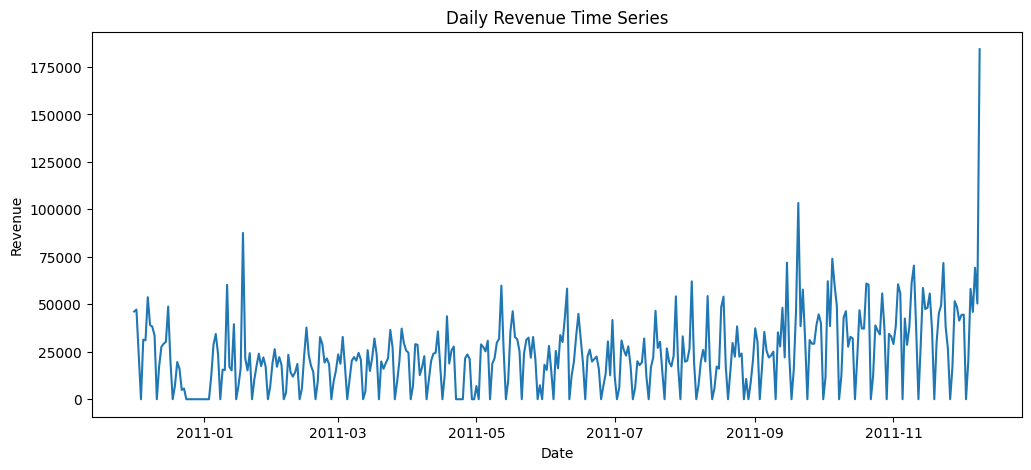

In [10]:
plt.figure(figsize=(12,5))

plt.plot(sales["ds"], sales["y"])

plt.title("Daily Revenue Time Series")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

#### Train Prophet Model

In [11]:
model = Prophet()

model.fit(sales)

13:56:49 - cmdstanpy - INFO - Chain [1] start processing
13:56:49 - cmdstanpy - INFO - Chain [1] done processing


#### Generate Future Dates and Forcast future sales

In [12]:
future = model.make_future_dataframe(periods=30)

In [13]:
forecast = model.predict(future)

#### Forcast Preview

In [14]:
forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(10)

,ds,yhat,yhat_lower,yhat_upper
394,2011-12-30,51428.680200,34880.881275,69783.488665
395,2011-12-31,24455.091505,7646.128526,42115.449419
396,2012-01-01,39378.901903,20926.957255,56542.883459
397,2012-01-02,50389.959497,32219.689867,67381.817830
398,2012-01-03,56796.592334,40046.863624,75016.670206
399,2012-01-04,54341.494892,36487.048181,71475.627399
400,2012-01-05,61643.027055,43430.247563,79634.947020
401,2012-01-06,52674.278032,37025.429563,69391.581869
402,2012-01-07,25700.689337,7566.347359,42722.576678
403,2012-01-08,40624.499735,22689.932037,57302.260575


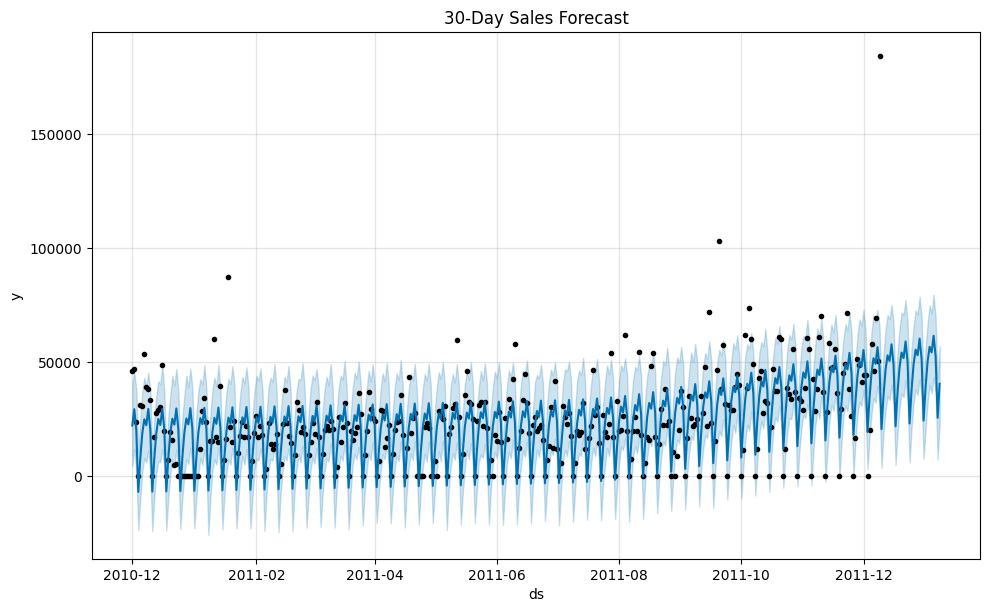

In [15]:
fig = model.plot(forecast)
plt.title("30-Day Sales Forecast")
plt.show()

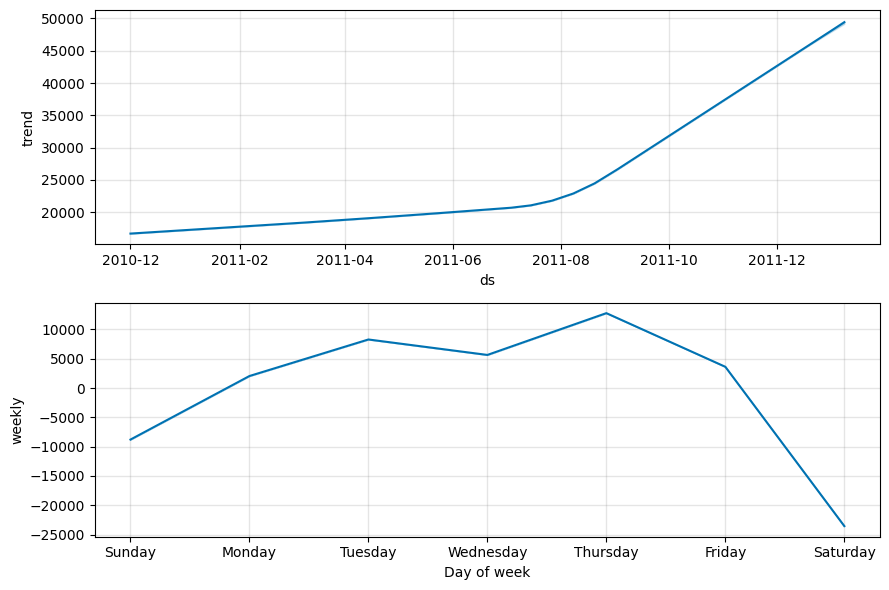

In [16]:
model.plot_components(forecast)
plt.show()

#### Save Forecast CSV

In [17]:
import os

os.makedirs("../../exports", exist_ok=True)

forecast.to_csv("../../exports/forecast_results.csv", index=False)

print("Forecast results saved successfully!")

Forecast results saved successfully!


#### Save Profet Model

In [18]:
import os
import joblib

os.makedirs("../../models", exist_ok=True)

joblib.dump(model, "../../models/prophet_model.pkl")

print("Prophet model saved successfully!")

Prophet model saved successfully!


#### MLflow Experiment Tracking

In [19]:
%pip install mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import mlflow

while mlflow.active_run() is not None:
    mlflow.end_run()

print("All active MLflow runs ended.")

All active MLflow runs ended.


In [32]:
import mlflow
import os

os.makedirs("../../mlruns", exist_ok=True)
mlflow.set_tracking_uri("../../mlruns")

with mlflow.start_run(run_name="prophet_forecast_run", nested=True):
    mlflow.log_param("model", "Prophet")
    mlflow.log_param("forecast_days", 30)

print("MLflow run logged successfully!")

MlflowException: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.